In [2]:
import pandas as pd
from pathlib import Path
import pyarrow

# Update this path to your sleep-scored parquet file
parquet_path = Path("/mnt/harris/hypnose/hypnose_eeg/derivatives/sub-066_id-427/ses-001_date-20260717/saved_results/sub-066_ses-001_recording-001_2026-07-17_13_40_01_somnotate_predictions.parquet")

sleep_df = pd.read_parquet(parquet_path)

print(f"Loaded {parquet_path}")
print(f"Rows: {len(sleep_df):,} | Columns: {sleep_df.shape[1]}")
sleep_df.head()

Loaded /mnt/harris/hypnose/hypnose_eeg/derivatives/sub-066_id-427/ses-001_date-20260717/saved_results/sub-066_ses-001_recording-001_2026-07-17_13_40_01_somnotate_predictions.parquet
Rows: 256,240 | Columns: 10


,time_s,label,label_model,label_output,segment_id,kind,prob_wake,prob_nrem,prob_rem,prob_undef
0,0.0,0,1,0,0,signal,1.0,2.526451e-11,9.689391e-19,0.0
1,1.0,0,1,0,0,signal,1.0,1.835255e-09,1.988701e-22,0.0
2,2.0,0,1,0,0,signal,1.0,7.323096e-12,3.310262e-28,0.0
3,3.0,0,1,0,0,signal,1.0,1.391053e-13,2.144903e-35,0.0
4,4.0,0,1,0,0,signal,1.0,1.085064e-08,4.010148e-21,0.0


In [3]:
import mne
fif_path = Path("/mnt/harris/hypnose/hypnose_eeg/derivatives/sub-066_id-427/ses-001_date-20260717/ephys/sub-066_ses-001_recording-001_2026-07-17_13_40_01_resampled-128hz_raw.fif")
raw = mne.io.read_raw_fif(fif_path, preload=False, verbose="ERROR")

print(f"Loaded .fif: {fif_path}")
print(raw)

Loaded .fif: /mnt/harris/hypnose/hypnose_eeg/derivatives/sub-066_id-427/ses-001_date-20260717/ephys/sub-066_ses-001_recording-001_2026-07-17_13_40_01_resampled-128hz_raw.fif
<Raw | sub-066_ses-001_recording-001_2026-07-17_13_40_01_resampled-128hz_raw.fif, 3 x 32798720 (256240.0 s), ~8 KiB, data not loaded>


In [4]:
raw

<Raw | sub-066_ses-001_recording-001_2026-07-17_13_40_01_resampled-128hz_raw.fif, 3 x 32798720 (256240.0 s), ~8 KiB, data not loaded>

In [5]:
import numpy as np

# Compute non-overlapping 4-second delta power while retaining EEG/EMG channels.
if "aligned_raw" not in globals():
    eeg_emg_picks = mne.pick_types(raw.info, eeg=True, emg=True, exclude=[])
    if len(eeg_emg_picks) == 0:
        raise ValueError("The FIF file contains no channels typed as EEG or EMG.")
    aligned_raw = raw.copy().pick(eeg_emg_picks)
epoch_seconds = 4.0
sfreq = float(aligned_raw.info["sfreq"])
epoch_samples = int(round(epoch_seconds * sfreq))
n_epochs = aligned_raw.n_times // epoch_samples

scores = sleep_df[["time_s", "label"]].copy()
scores["epoch_id"] = np.floor(scores["time_s"] / epoch_seconds).astype("int64")
score_counts = scores.groupby("epoch_id").size()
complete_score_epochs = score_counts[score_counts == int(epoch_seconds)].index
epoch_labels = (
    scores[scores["epoch_id"].isin(complete_score_epochs)]
    .groupby("epoch_id")["label"]
    .agg(lambda values: values.mode().iloc[0])
)

# Welch settings give sufficient resolution around the 0.5--4 Hz delta band.
n_per_seg = min(epoch_samples, int(round(2 * sfreq)))
n_fft = 1 << (n_per_seg - 1).bit_length()
n_overlap = n_per_seg // 2
rows = []
chunk_epochs = 512
for first_epoch in range(0, n_epochs, chunk_epochs):
    last_epoch = min(first_epoch + chunk_epochs, n_epochs)
    start = first_epoch * epoch_samples
    stop = last_epoch * epoch_samples
    samples = aligned_raw.get_data(start=start, stop=stop)
    batch = samples.reshape(len(aligned_raw.ch_names), last_epoch - first_epoch, epoch_samples)
    batch = np.moveaxis(batch, 1, 0)  # epochs x channels x samples
    batch *= 1e6  # MNE stores EEG/EMG in volts; calculate PSD in microvolts.
    psd, frequencies = mne.time_frequency.psd_array_welch(
        batch, sfreq=sfreq, fmin=0.5, fmax=4.0,
        n_fft=n_fft, n_per_seg=n_per_seg, n_overlap=n_overlap, verbose=False,
    )
    delta_power = np.trapezoid(psd, frequencies, axis=-1)
    for offset, power in enumerate(delta_power):
        epoch_id = first_epoch + offset
        if epoch_id not in epoch_labels.index:
            continue
        rows.append({
            "epoch_id": epoch_id,
            "time_from_recording_start_s": epoch_id * epoch_seconds,
            "label": epoch_labels.loc[epoch_id],
            **dict(zip(aligned_raw.ch_names, power)),
        })

delta_power_df = pd.DataFrame(rows)
print(f"Computed {len(delta_power_df):,} complete 4-second epochs")
print(f"Channels: {aligned_raw.ch_names} (delta power in uV^2)")
delta_power_df.head()

Computed 64,060 complete 4-second epochs
Channels: ['EEG1A-B', 'EEG2A-B', 'EMG'] (delta power in uV^2)


,epoch_id,time_from_recording_start_s,label,EEG1A-B,EEG2A-B,EMG
0,0,0.0,0,357.555702,178.146424,344.634640
1,1,4.0,0,287.798769,92.960343,306.224192
2,2,8.0,0,274.499950,147.469212,598.230672
3,3,12.0,0,376.668716,243.540739,851.605159
4,4,16.0,0,509.670132,94.761022,72.687353


In [6]:
power_cols = [c for c in delta_power_df.columns if c not in ["epoch_id", "time_from_recording_start_s", "label"]]

mean_delta_by_label = delta_power_df.groupby("label")[power_cols].mean()
print(mean_delta_by_label)

            EEG1A-B       EEG2A-B         EMG
label                                        
0        558.283839    228.082169  331.450215
1       1218.916488    358.772425    4.965289
2        466.518716    197.186555    4.901858
3      23533.653863  23515.627017  591.169815


In [7]:
# Count occurrences where label == 3 in the per-second scoring table
count_label3 = (sleep_df["label"] == 3).sum()
print(f"label == 3 appears {count_label3:,} times in sleep_df")

# Optional: same count in 4-second epoch table
count_label3_epochs = (delta_power_df["label"] == 3).sum()
print(f"label == 3 appears {count_label3_epochs:,} times in delta_power_df")

label == 3 appears 34 times in sleep_df
label == 3 appears 6 times in delta_power_df


<IPython.core.display.Javascript object>

matplotlib backend: notebook
Showing first 5 hours only.
Showing channel: EEG1A-B
Values above 20000 are hidden.


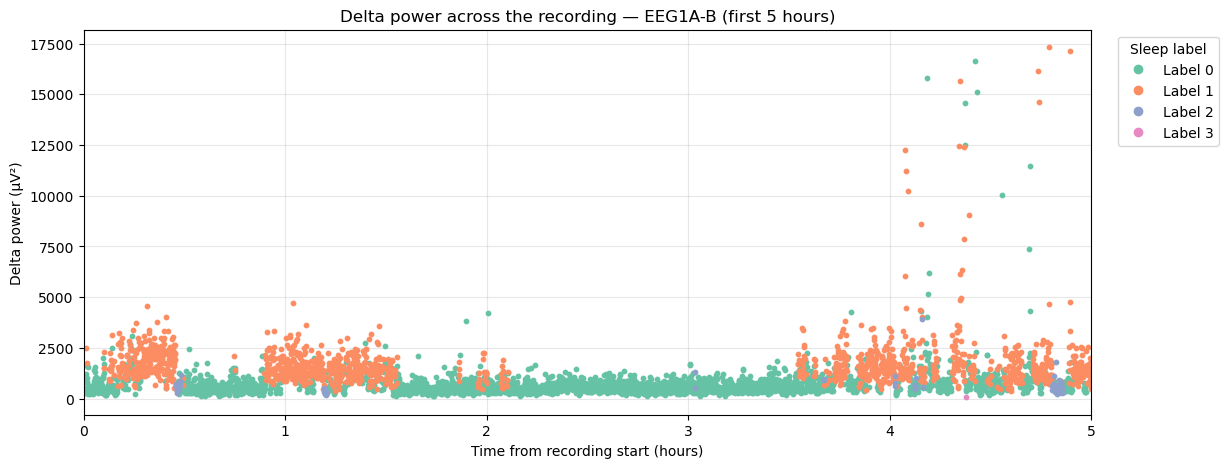

In [12]:
backend_used = None
for candidate in ("widget", "notebook", "inline"):
    try:
        get_ipython().run_line_magic("matplotlib", candidate)
        backend_used = candidate
        break
    except Exception:
        pass

import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.widgets import RadioButtons

if delta_power_df.empty:
    raise ValueError("delta_power_df is empty.")

max_delta_to_plot = 20000
max_hours_to_plot = 5
channel = power_cols[0]  # EEG channel 1

plot_df = delta_power_df.copy()
plot_df["time_h"] = plot_df["time_from_recording_start_s"] / 3600.0
plot_df = plot_df.loc[plot_df["time_h"] <= max_hours_to_plot].copy()

if plot_df.empty:
    raise ValueError(f"No data found in the first {max_hours_to_plot} hours.")

labels = sorted(plot_df["label"].dropna().unique())
cmap = plt.get_cmap("Set2")
label_colors = {label: cmap(i % cmap.N) for i, label in enumerate(labels)}

x = plot_df["time_h"].to_numpy()
label_array = plot_df["label"].to_numpy()
label_masks = {label: label_array == label for label in labels}

plt.close("all")
fig, ax = plt.subplots(figsize=(13, 5))

y = plot_df[channel].to_numpy()
valid = np.isfinite(y) & (y <= max_delta_to_plot)
y_plot = np.where(valid, y, np.nan)

scatter_artists = {}
for label in labels:
    mask = label_masks[label] & valid
    scatter_artists[label] = ax.scatter(
        x[mask],
        y[mask],
        s=10,
        color=label_colors[label],
        zorder=2,
        label=f"Label {label}",
    )

ax.set_title(f"Delta power across the recording — {channel} (first {max_hours_to_plot} hours)")
ax.set_xlabel("Time from recording start (hours)")
ax.set_ylabel("Delta power (µV²)")
ax.set_xlim(0, max_hours_to_plot)
ax.grid(True, alpha=0.3)

finite_y = y[valid]
if finite_y.size:
    ymin = finite_y.min()
    ymax = finite_y.max()
    pad = max((ymax - ymin) * 0.05, 1e-12)
    ax.set_ylim(ymin - pad, ymax + pad)

handles = [
    Line2D([0], [0], marker="o", linestyle="", color=label_colors[label], label=f"Label {label}", markersize=6)
    for label in labels
]
ax.legend(handles=handles, title="Sleep label", bbox_to_anchor=(1.02, 1), loc="upper left")

print(f"matplotlib backend: {backend_used}")
print(f"Showing first {max_hours_to_plot} hours only.")
print(f"Showing channel: {channel}")
print(f"Values above {max_delta_to_plot} are hidden.")

if backend_used == "widget":
    display(fig.canvas)
else:
    display(fig)


<IPython.core.display.Javascript object>

Computed 64,060 complete 4-second epochs
Showing channel: EEG1A-B; ratios above 10 are hidden.


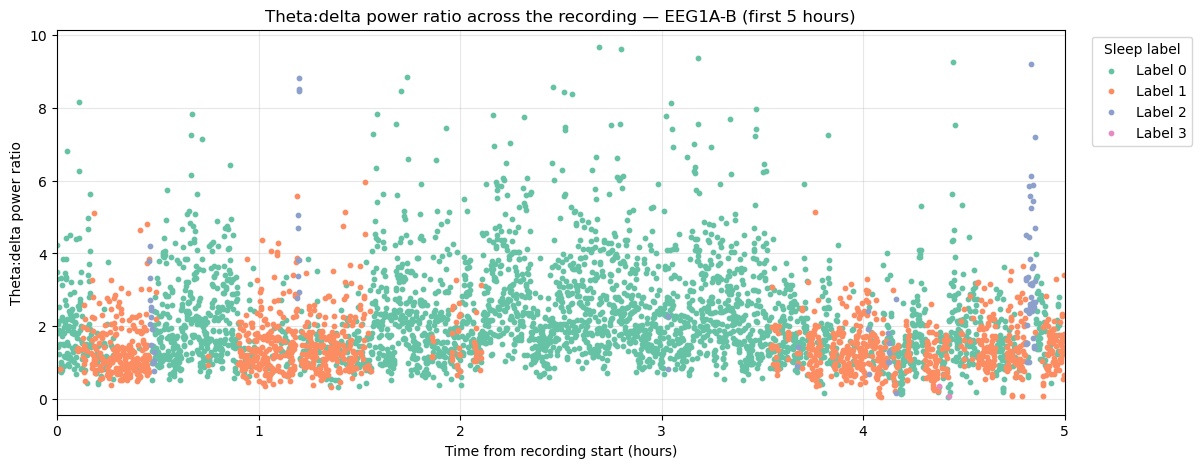

In [13]:
# Compute and plot the theta:delta power ratio in the same 4-second epochs.
theta_delta_rows = []
for first_epoch in range(0, n_epochs, chunk_epochs):
    last_epoch = min(first_epoch + chunk_epochs, n_epochs)
    start = first_epoch * epoch_samples
    stop = last_epoch * epoch_samples
    samples = aligned_raw.get_data(start=start, stop=stop)
    batch = samples.reshape(len(aligned_raw.ch_names), last_epoch - first_epoch, epoch_samples)
    batch = np.moveaxis(batch, 1, 0) * 1e6  # epochs x channels x samples, in microvolts
    psd, frequencies = mne.time_frequency.psd_array_welch(
        batch, sfreq=sfreq, fmin=0.5, fmax=10.0,
        n_fft=n_fft, n_per_seg=n_per_seg, n_overlap=n_overlap, verbose=False,
    )
    delta_mask = (frequencies >= 0.5) & (frequencies <= 4.0)
    theta_mask = (frequencies >= 4.0) & (frequencies <= 10.0)
    delta = np.trapezoid(psd[..., delta_mask], frequencies[delta_mask], axis=-1)
    theta = np.trapezoid(psd[..., theta_mask], frequencies[theta_mask], axis=-1)
    ratio = np.divide(theta, delta, out=np.full_like(theta, np.nan), where=delta > 0)

    for offset, channel_ratios in enumerate(ratio):
        epoch_id = first_epoch + offset
        if epoch_id not in epoch_labels.index:
            continue
        theta_delta_rows.append({
            "epoch_id": epoch_id,
            "time_from_recording_start_s": epoch_id * epoch_seconds,
            "label": epoch_labels.loc[epoch_id],
            **dict(zip(aligned_raw.ch_names, channel_ratios)),
        })

theta_delta_ratio_df = pd.DataFrame(theta_delta_rows)
ratio_cols = [
    c for c in theta_delta_ratio_df.columns
    if c not in ["epoch_id", "time_from_recording_start_s", "label"]
]
if theta_delta_ratio_df.empty:
    raise ValueError("theta_delta_ratio_df is empty.")

max_ratio_to_plot = 10
max_hours_to_plot = 5
channel = ratio_cols[0]  # EEG channel 1
ratio_plot_df = theta_delta_ratio_df.copy()
ratio_plot_df["time_h"] = ratio_plot_df["time_from_recording_start_s"] / 3600.0
ratio_plot_df = ratio_plot_df.loc[ratio_plot_df["time_h"] <= max_hours_to_plot].copy()

labels = sorted(ratio_plot_df["label"].dropna().unique())
cmap = plt.get_cmap("Set2")
label_colors = {label: cmap(i % cmap.N) for i, label in enumerate(labels)}
x = ratio_plot_df["time_h"].to_numpy()
y = ratio_plot_df[channel].to_numpy()
label_array = ratio_plot_df["label"].to_numpy()
valid = np.isfinite(y) & (y <= max_ratio_to_plot)

fig, ax = plt.subplots(figsize=(13, 5))
for label in labels:
    mask = (label_array == label) & valid
    ax.scatter(x[mask], y[mask], s=10, color=label_colors[label], zorder=2, label=f"Label {label}")

ax.set_title(f"Theta:delta power ratio across the recording — {channel} (first {max_hours_to_plot} hours)")
ax.set_xlabel("Time from recording start (hours)")
ax.set_ylabel("Theta:delta power ratio")
ax.set_xlim(0, max_hours_to_plot)
ax.grid(True, alpha=0.3)
finite_y = y[valid]
if finite_y.size:
    ymin, ymax = finite_y.min(), finite_y.max()
    pad = max((ymax - ymin) * 0.05, 1e-12)
    ax.set_ylim(ymin - pad, ymax + pad)
ax.legend(title="Sleep label", bbox_to_anchor=(1.02, 1), loc="upper left")

print(f"Computed {len(theta_delta_ratio_df):,} complete 4-second epochs")
print(f"Showing channel: {channel}; ratios above {max_ratio_to_plot} are hidden.")
if backend_used == "widget":
    display(fig.canvas)
else:
    display(fig)
